In [99]:
#
# Project:
#      PyTorch Dojo (https://github.com/wo3kie/ml-dojo)
#
# Author:
#      Lukasz Czerwinski (https://www.lukaszczerwinski.pl/)
#

In [100]:
import torch

import import_ipynb
from perceptron_log import PerceptronLog # type: ignore

import matplotlib.pyplot as plt

In [101]:
def plot_boolean_function(title, bool_fn, slope=1.0, intercept=0.0):
    x = torch.tensor([False, False, True, True])
    y = torch.tensor([False, True, False, True])
    z = torch.tensor([bool_fn(x[i], y[i]).item() for i in range(4)])

    plt.title(title)
    
    plt.xlabel('x')
    plt.xlim(-0.5, 1.5)
    plt.ylabel('y')
    plt.ylim(-0.5, 1.5)

    plt.scatter(x[z], y[z], color="green")
    plt.scatter(x[~z], y[~z], color="red")

    line_x = torch.tensor([-0.5, 1.5], dtype=torch.float32)
    line_y = slope * line_x + intercept
    plt.plot(line_x, line_y, color="lightgrey")

    plt.legend(['1', '0'], loc='upper left')
    plt.show()


In [102]:
def learn_perceptron_log(bool_fn, epochs=500):
    x = (torch.randn(500, 2, dtype=torch.float32) > 0).float()
    y = bool_fn(x[:, 0], x[:, 1]).float().unsqueeze(1)

    model = PerceptronLog(2, 1)
    criterion = model.get_loss_fn()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

    for _ in range(epochs):
        optimizer.zero_grad()

        outputs = model(x)
        loss = criterion(outputs, y)
        
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        weights = model.linear.weight
        bias = model.linear.bias

        return (weights[0].item(), weights[1].item()), bias.item()

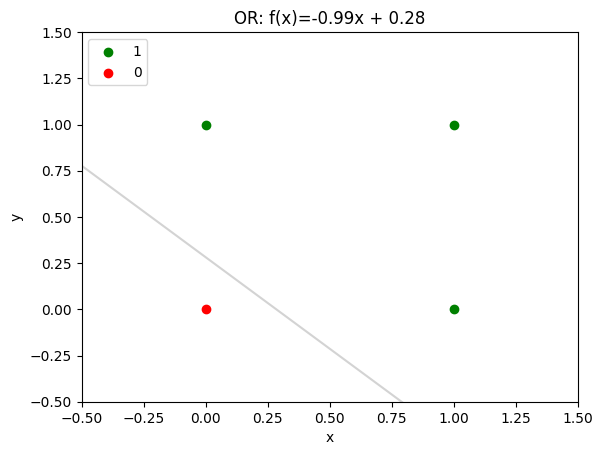

In [103]:
bool_fn = torch.logical_or
((w1, w2), b) = learn_perceptron_log(bool_fn, epochs=500)
plot_boolean_function(f'OR: f(x)={-w1/w2:.2f}x + {-b/w2:.2f}', bool_fn, slope=-w1/w2, intercept=-b/w2)

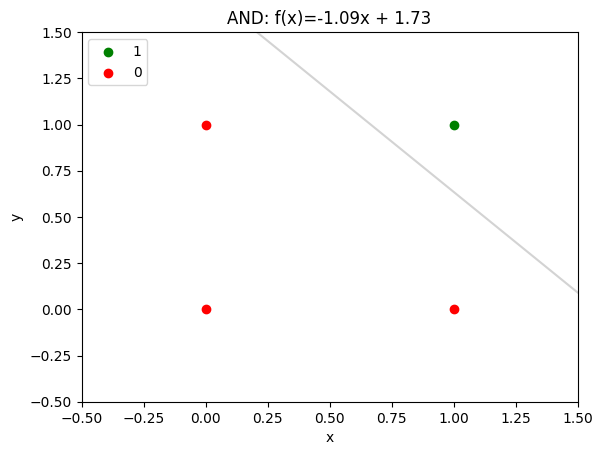

In [104]:
bool_fn = torch.logical_and
((w1, w2), b) = learn_perceptron_log(bool_fn, epochs=500)
plot_boolean_function(f'AND: f(x)={-w1/w2:.2f}x + {-b/w2:.2f}', bool_fn, slope=-w1/w2, intercept=-b/w2)

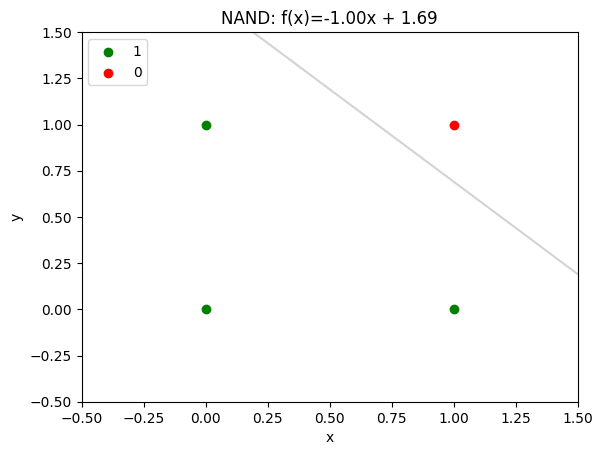

In [105]:
bool_fn = lambda x, y: torch.logical_not(torch.logical_and(x, y))
((w1, w2), b) = learn_perceptron_log(bool_fn, epochs=500)
plot_boolean_function(f'NAND: f(x)={-w1/w2:.2f}x + {-b/w2:.2f}', bool_fn, slope=-w1/w2, intercept=-b/w2)

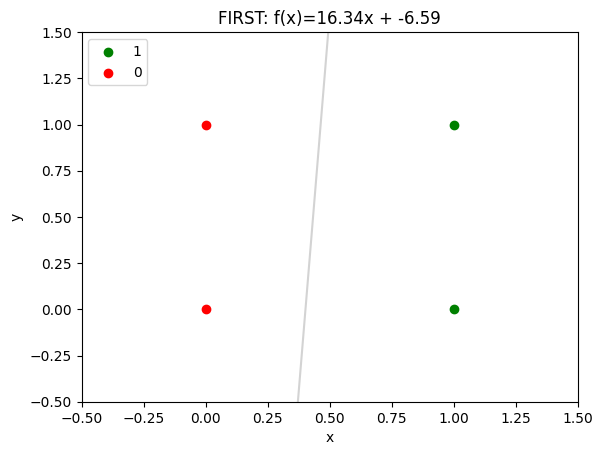

In [106]:
bool_fn = lambda x, _: x
((w1, w2), b) = learn_perceptron_log(bool_fn, epochs=500)
plot_boolean_function(f'FIRST: f(x)={-w1/w2:.2f}x + {-b/w2:.2f}', bool_fn, slope=-w1/w2, intercept=-b/w2)

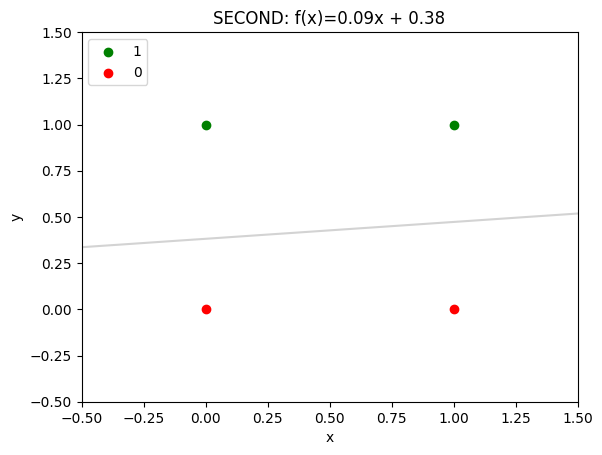

In [107]:
bool_fn = lambda _, y: y
((w1, w2), b) = learn_perceptron_log(bool_fn, epochs=500)
plot_boolean_function(f'SECOND: f(x)={-w1/w2:.2f}x + {-b/w2:.2f}', bool_fn, slope=-w1/w2, intercept=-b/w2)

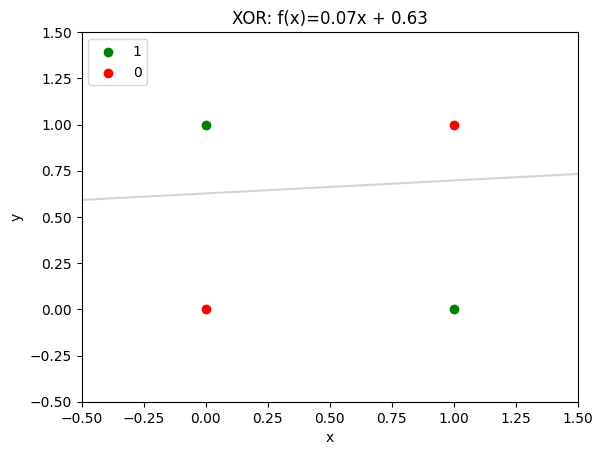

In [108]:
bool_fn = torch.logical_xor
((w1, w2), b) = learn_perceptron_log(bool_fn, epochs=500)
plot_boolean_function(f'XOR: f(x)={-w1/w2:.2f}x + {-b/w2:.2f}', bool_fn, slope=-w1/w2, intercept=-b/w2)